In [2]:
#Import libraries and check GPU availability
import os
import torch
import clip
from PIL import Image
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import pickle
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Using device: {device}")
if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
print(f"🐍 Python version: {torch.__version__}")
print("✅ All imports successful!")

🖥️  Using device: cpu
🐍 Python version: 2.8.0
✅ All imports successful!


In [2]:
pip uninstall clip clipy clip-by-openai -y

Found existing installation: clip 0.2.0
Uninstalling clip-0.2.0:
  Successfully uninstalled clip-0.2.0
Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /private/var/folders/06/hz9fr33s3fl0hl8nh58pm9_m0000gn/T/pip-req-build-ohck_g2w
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /private/var/folders/06/hz9fr33s3fl0hl8nh58pm9_m0000gn/T/pip-req-build-ohck_g2w
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369549 sha256=2e78c5e11177e56d42c898dc89a1bd131ad5459e56e30768775afcf8839b83c2
  Stored in directory: /private/var/folders/06/hz9fr33s3fl0hl8nh58pm9_m0000gn/T/pip-ephem-wheel-cache-jbakobn9/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [clip]


In [3]:
# Try to import CLIP with error handling
#Restart kernel before running this step
try:
    import clip
    print("✅ CLIP imported successfully")
    
    # Test if clip.load works
    available_models = clip.available_models()
    print(f"📋 Available CLIP models: {available_models[:3]}...")  # Show first 3
    
except ImportError as e:
    print("❌ CLIP import failed!")
    print(f"Error: {e}")
    print("\n🔧 SOLUTION:")
    print("1. Run: !pip uninstall clip clipy clip-by-openai -y")
    print("2. Run: !pip install git+https://github.com/openai/CLIP.git")
    print("3. Restart your kernel")
    raise ImportError("Please fix CLIP installation before continuing")

except AttributeError as e:
    print("❌ CLIP module doesn't have 'load' attribute!")
    print(f"Error: {e}")
    print("\n🔧 SOLUTION:")
    print("You likely have the wrong CLIP package installed.")
    print("1. Run: !pip uninstall clip clipy clip-by-openai -y")
    print("2. Run: !pip install git+https://github.com/openai/CLIP.git")
    print("3. Restart your kernel")
    raise ImportError("Please fix CLIP installation before continuing")

# Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Using device: {device}")
if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
print(f"🐍 PyTorch version: {torch.__version__}")
print("✅ All imports successful!")

✅ CLIP imported successfully
📋 Available CLIP models: ['RN50', 'RN101', 'RN50x4']...
🖥️  Using device: cpu
🐍 PyTorch version: 2.8.0
✅ All imports successful!


In [5]:
images_folder = "/Users/sriramlakkaraju/Desktop/github/RAGBot/flowers/rose"

# Verify the folder exists
if os.path.exists(images_folder):
    print(f"✅ Found images folder: {images_folder}")
    
    # Count images
    supported_formats = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
    image_files = [f for f in os.listdir(images_folder) 
                   if any(f.lower().endswith(fmt) for fmt in supported_formats)]
    print(f"📸 Found {len(image_files)} images")
    
    # Show first few filenames as examples
    if image_files:
        print("📋 Sample files:")
        for i, filename in enumerate(image_files[:5]):
            print(f"   {i+1}. {filename}")
        if len(image_files) > 5:
            print(f"   ... and {len(image_files) - 5} more")
else:
    print(f"❌ Folder not found: {images_folder}")
    print("Please update the 'images_folder' variable with the correct path to your images")

✅ Found images folder: /Users/sriramlakkaraju/Desktop/github/RAGBot/flowers/rose
📸 Found 497 images
📋 Sample files:
   1. 16209331331_343c899d38.jpg
   2. 5777669976_a205f61e5b.jpg
   3. 4860145119_b1c3cbaa4e_n.jpg
   4. 15011625580_7974c44bce.jpg
   5. 17953368844_be3d18cf30_m.jpg
   ... and 492 more


In [6]:
#Load CLIP Model

print("🔄 Loading CLIP model...")

# You can change the model here:
# "ViT-B/32" - Fast, good quality (default)
# "ViT-B/16" - Slower, better quality  
# "ViT-L/14" - Slowest, best quality
model_name = "ViT-B/32"

model, preprocess = clip.load(model_name, device=device)
print(f"✅ Loaded CLIP model: {model_name}")
print(f"📊 Model parameters: ~{sum(p.numel() for p in model.parameters()):,}")

🔄 Loading CLIP model...


100%|███████████████████████████████████████| 338M/338M [00:14<00:00, 24.4MiB/s]


✅ Loaded CLIP model: ViT-B/32
📊 Model parameters: ~151,277,313


In [7]:
#Helper functions for display
def load_image_paths(folder):
    """Load all image paths from folder"""
    supported_formats = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
    paths = []
    for filename in os.listdir(folder):
        if any(filename.lower().endswith(fmt) for fmt in supported_formats):
            paths.append(os.path.join(folder, filename))
    return sorted(paths)

def display_results(query, results, max_display=3):
    """Display search results with images"""
    print(f"\n🔍 Query: '{query}'")
    print("=" * 50)
    
    fig, axes = plt.subplots(1, min(len(results), max_display), figsize=(15, 5))
    if len(results) == 1:
        axes = [axes]
    
    for i, (image_path, score) in enumerate(results[:max_display]):
        # Load and display image
        img = Image.open(image_path)
        
        if len(results) > 1:
            axes[i].imshow(img)
            axes[i].set_title(f"#{i+1}: {os.path.basename(image_path)}\nSimilarity: {score:.3f}", 
                            fontsize=10)
            axes[i].axis('off')
        else:
            axes[0].imshow(img)
            axes[0].set_title(f"#{i+1}: {os.path.basename(image_path)}\nSimilarity: {score:.3f}", 
                            fontsize=10)
            axes[0].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print all results
    print("\n📋 All results:")
    for i, (image_path, score) in enumerate(results, 1):
        filename = os.path.basename(image_path)
        print(f"   {i}. {filename} (similarity: {score:.3f})")

print("✅ Helper functions loaded!")

✅ Helper functions loaded!


In [8]:
#Compute Image Embeddings
def compute_image_embeddings(images_folder, force_recompute=False):
    """Compute embeddings for all images"""
    cache_file = os.path.join(images_folder, "embeddings_cache.pkl")
    
    # Check for cached embeddings
    if os.path.exists(cache_file) and not force_recompute:
        print("🔄 Loading cached embeddings...")
        with open(cache_file, 'rb') as f:
            cache_data = pickle.load(f)
        print("✅ Cached embeddings loaded!")
        return cache_data['embeddings'], cache_data['paths']
    
    # Load image paths
    image_paths = load_image_paths(images_folder)
    print(f"🔄 Computing embeddings for {len(image_paths)} images...")
    
    embeddings = []
    successful_paths = []
    
    for i, image_path in enumerate(image_paths):
        try:
            # Load and preprocess image
            image = Image.open(image_path).convert('RGB')
            image_tensor = preprocess(image).unsqueeze(0).to(device)
            
            # Get embedding
            with torch.no_grad():
                embedding = model.encode_image(image_tensor)
                embedding = embedding / embedding.norm(dim=-1, keepdim=True)
            
            embeddings.append(embedding.cpu().numpy())
            successful_paths.append(image_path)
            
            # Progress update
            if (i + 1) % 10 == 0 or i == len(image_paths) - 1:
                print(f"   Progress: {i + 1}/{len(image_paths)} ({100*(i+1)/len(image_paths):.1f}%)")
                
        except Exception as e:
            print(f"   ⚠️  Error processing {os.path.basename(image_path)}: {str(e)}")
    
    if not embeddings:
        raise ValueError("No images could be processed successfully")
    
    embeddings_array = np.vstack(embeddings)
    
    # Cache the results
    print("💾 Caching embeddings...")
    cache_data = {
        'embeddings': embeddings_array,
        'paths': successful_paths
    }
    with open(cache_file, 'wb') as f:
        pickle.dump(cache_data, f)
    
    print(f"✅ Successfully processed {len(embeddings)} images!")
    return embeddings_array, successful_paths

# Run the embedding computation
# Set force_recompute=True if you want to recompute embeddings
image_embeddings, image_paths = compute_image_embeddings(images_folder, force_recompute=False)

🔄 Computing embeddings for 497 images...
   Progress: 10/497 (2.0%)
   Progress: 20/497 (4.0%)
   Progress: 30/497 (6.0%)
   Progress: 40/497 (8.0%)
   Progress: 50/497 (10.1%)
   Progress: 60/497 (12.1%)
   Progress: 70/497 (14.1%)
   Progress: 80/497 (16.1%)
   Progress: 90/497 (18.1%)
   Progress: 100/497 (20.1%)
   Progress: 110/497 (22.1%)
   Progress: 120/497 (24.1%)
   Progress: 130/497 (26.2%)
   Progress: 140/497 (28.2%)
   Progress: 150/497 (30.2%)
   Progress: 160/497 (32.2%)
   Progress: 170/497 (34.2%)
   Progress: 180/497 (36.2%)
   Progress: 190/497 (38.2%)
   Progress: 200/497 (40.2%)
   Progress: 210/497 (42.3%)
   Progress: 220/497 (44.3%)
   Progress: 230/497 (46.3%)
   Progress: 240/497 (48.3%)
   Progress: 250/497 (50.3%)
   Progress: 260/497 (52.3%)
   Progress: 270/497 (54.3%)
   Progress: 280/497 (56.3%)
   Progress: 290/497 (58.4%)
   Progress: 300/497 (60.4%)
   Progress: 310/497 (62.4%)
   Progress: 320/497 (64.4%)
   Progress: 330/497 (66.4%)
   Progress: 34

In [9]:
#Text Search Function
def search_images(query, top_k=5):
    """Search for images similar to text query"""
    # Encode the text query
    text_tokens = clip.tokenize([query]).to(device)
    
    with torch.no_grad():
        text_embedding = model.encode_text(text_tokens)
        text_embedding = text_embedding / text_embedding.norm(dim=-1, keepdim=True)
    
    # Calculate similarities
    similarities = cosine_similarity(text_embedding.cpu().numpy(), image_embeddings)[0]
    
    # Get top-k results
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    results = []
    for idx in top_indices:
        image_path = image_paths[idx]
        score = similarities[idx]
        results.append((image_path, float(score)))
    
    return results

print("✅ Search function ready!")

✅ Search function ready!


🔍 Searching for: 'a pink rose'

🔍 Query: 'a pink rose'


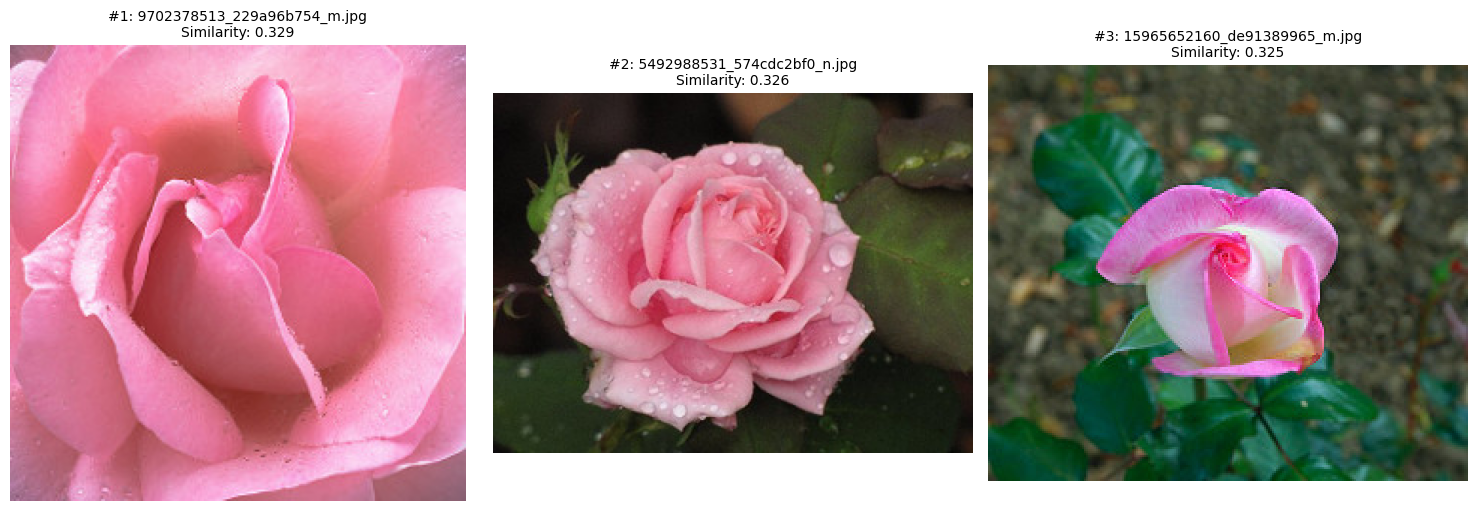


📋 All results:
   1. 9702378513_229a96b754_m.jpg (similarity: 0.329)
   2. 5492988531_574cdc2bf0_n.jpg (similarity: 0.326)
   3. 15965652160_de91389965_m.jpg (similarity: 0.325)
   4. 5159317458_bbb22e2f65_n.jpg (similarity: 0.323)
   5. 3667366832_7a8017c528_n.jpg (similarity: 0.323)


In [10]:
#Single search
test_query = "a pink rose"

print(f"🔍 Searching for: '{test_query}'")
results = search_images(test_query, top_k=5)

# Display results
display_results(test_query, results, max_display=3)

🔍 Searching for: 'a white tulip in a garden'

🔍 Query: 'a white tulip in a garden'


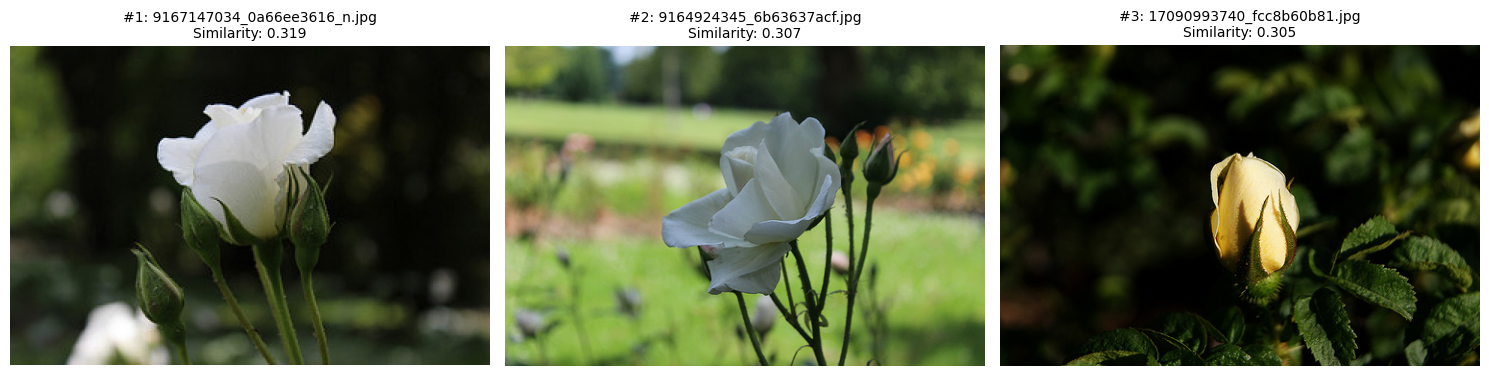


📋 All results:
   1. 9167147034_0a66ee3616_n.jpg (similarity: 0.319)
   2. 9164924345_6b63637acf.jpg (similarity: 0.307)
   3. 17090993740_fcc8b60b81.jpg (similarity: 0.305)
   4. 4325834819_ab56661dcc_m.jpg (similarity: 0.301)
   5. 16643944275_3cd4cd966c.jpg (similarity: 0.291)


In [11]:
#Single search
test_query = "a white tulip in a garden"

print(f"🔍 Searching for: '{test_query}'")
results = search_images(test_query, top_k=5)

# Display results
display_results(test_query, results, max_display=3)

🎯 Testing multiple queries...
You can modify the search_queries list above to test your own queries!

🔍 Query: 'a dog playing'


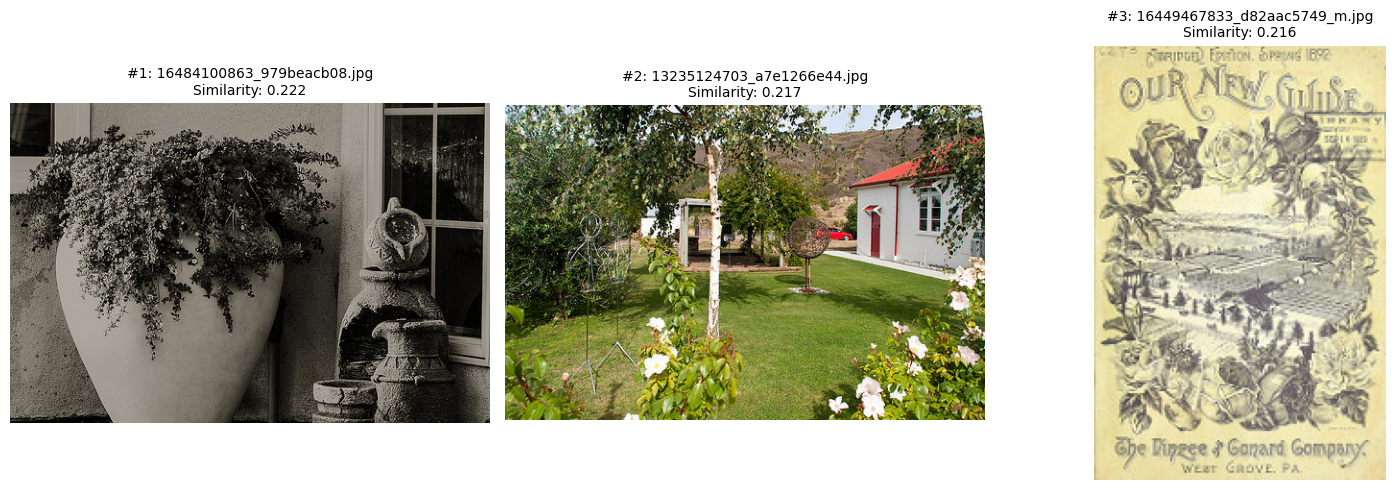


📋 All results:
   1. 16484100863_979beacb08.jpg (similarity: 0.222)
   2. 13235124703_a7e1266e44.jpg (similarity: 0.217)
   3. 16449467833_d82aac5749_m.jpg (similarity: 0.216)
   4. 5148639829_781eb7d346.jpg (similarity: 0.216)
   5. 15274443248_76b9f3eb24.jpg (similarity: 0.214)
   6. 3265902330_d8b1e44545.jpg (similarity: 0.212)

🔍 Query: 'beautiful sunset'


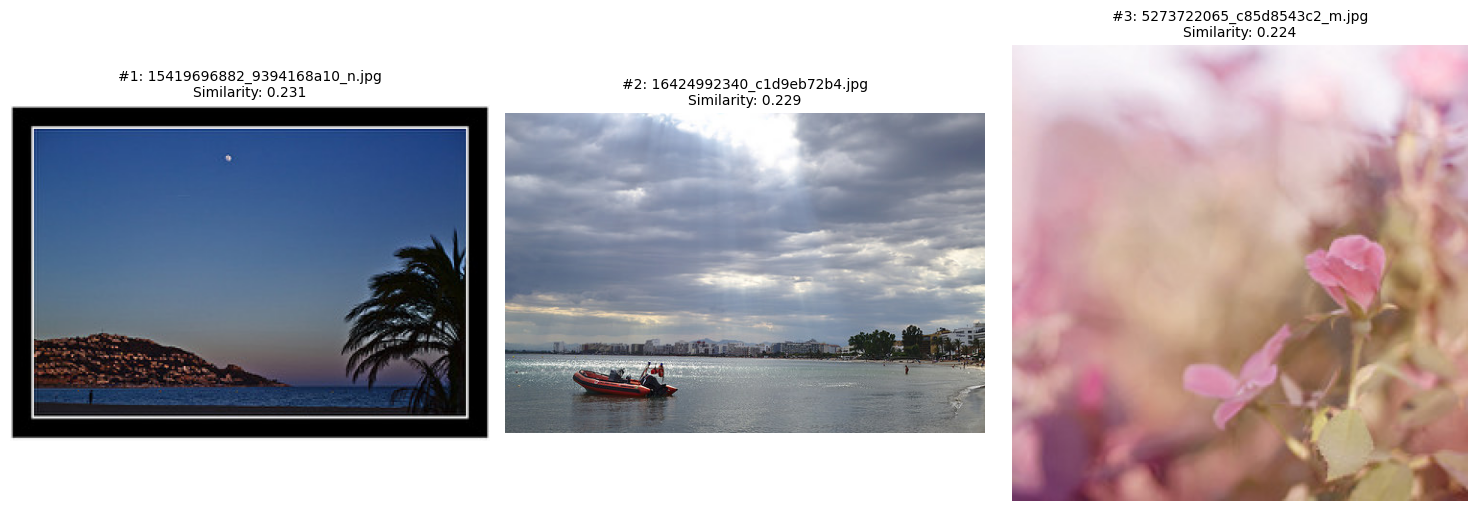


📋 All results:
   1. 15419696882_9394168a10_n.jpg (similarity: 0.231)
   2. 16424992340_c1d9eb72b4.jpg (similarity: 0.229)
   3. 5273722065_c85d8543c2_m.jpg (similarity: 0.224)
   4. 16374919860_4e445de29f_n.jpg (similarity: 0.222)
   5. 18376177250_86060cbdc9.jpg (similarity: 0.221)
   6. 5487945052_bcb8e9fc8b_m.jpg (similarity: 0.218)

🔍 Query: 'yellow tulips'


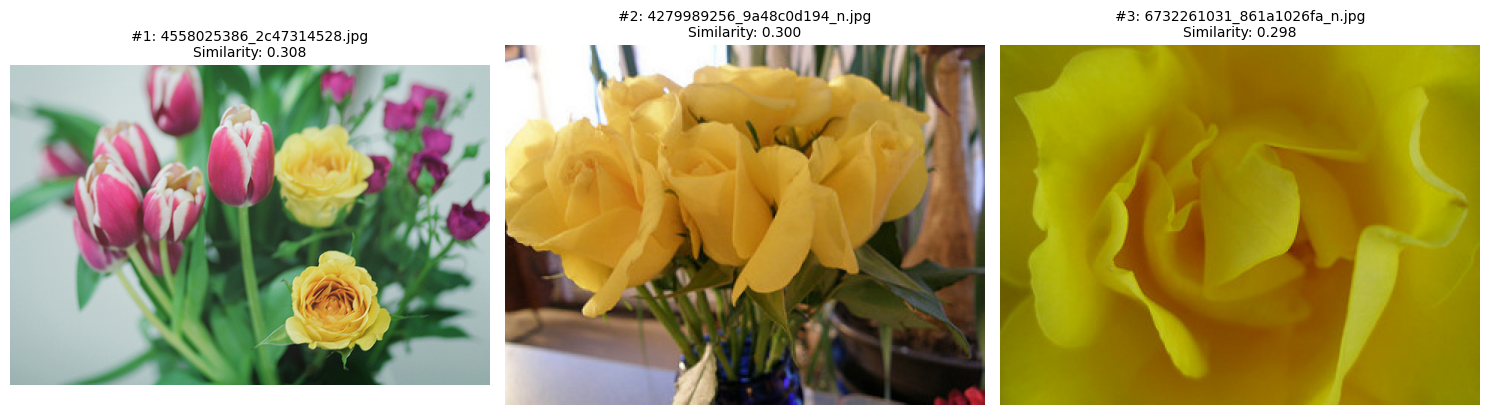


📋 All results:
   1. 4558025386_2c47314528.jpg (similarity: 0.308)
   2. 4279989256_9a48c0d194_n.jpg (similarity: 0.300)
   3. 6732261031_861a1026fa_n.jpg (similarity: 0.298)
   4. 12243068283_ee4c2683e2_n.jpg (similarity: 0.292)
   5. 4279990882_031482f8b6_n.jpg (similarity: 0.286)
   6. 12238827553_cf427bfd51_n.jpg (similarity: 0.279)

🔍 Query: 'red car'


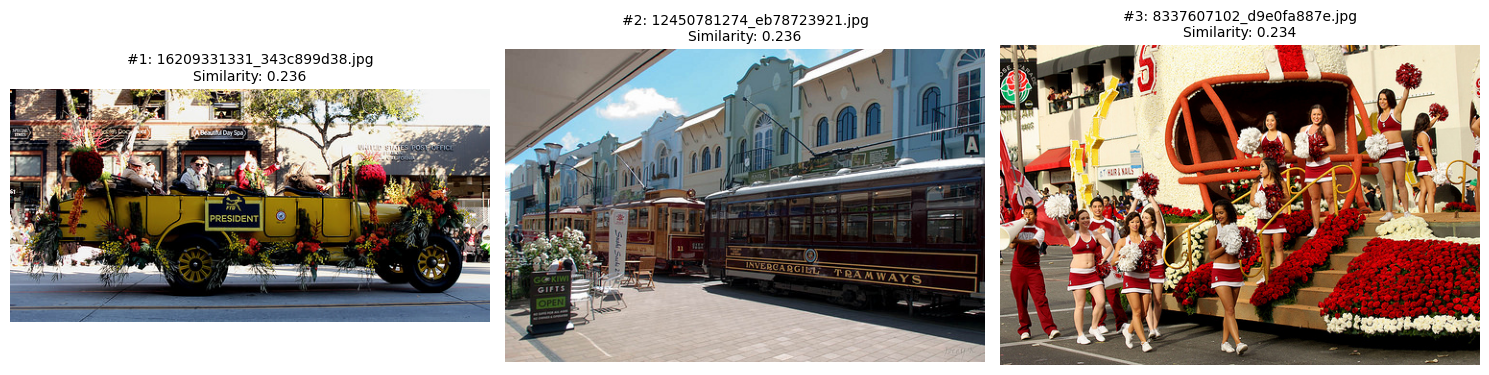


📋 All results:
   1. 16209331331_343c899d38.jpg (similarity: 0.236)
   2. 12450781274_eb78723921.jpg (similarity: 0.236)
   3. 8337607102_d9e0fa887e.jpg (similarity: 0.234)
   4. 3278709893_ba4956a572_n.jpg (similarity: 0.228)
   5. 16152175716_55d6968e08_n.jpg (similarity: 0.227)
   6. 19566556880_476c66c5ee_n.jpg (similarity: 0.227)

🔍 Query: 'flowers in garden'


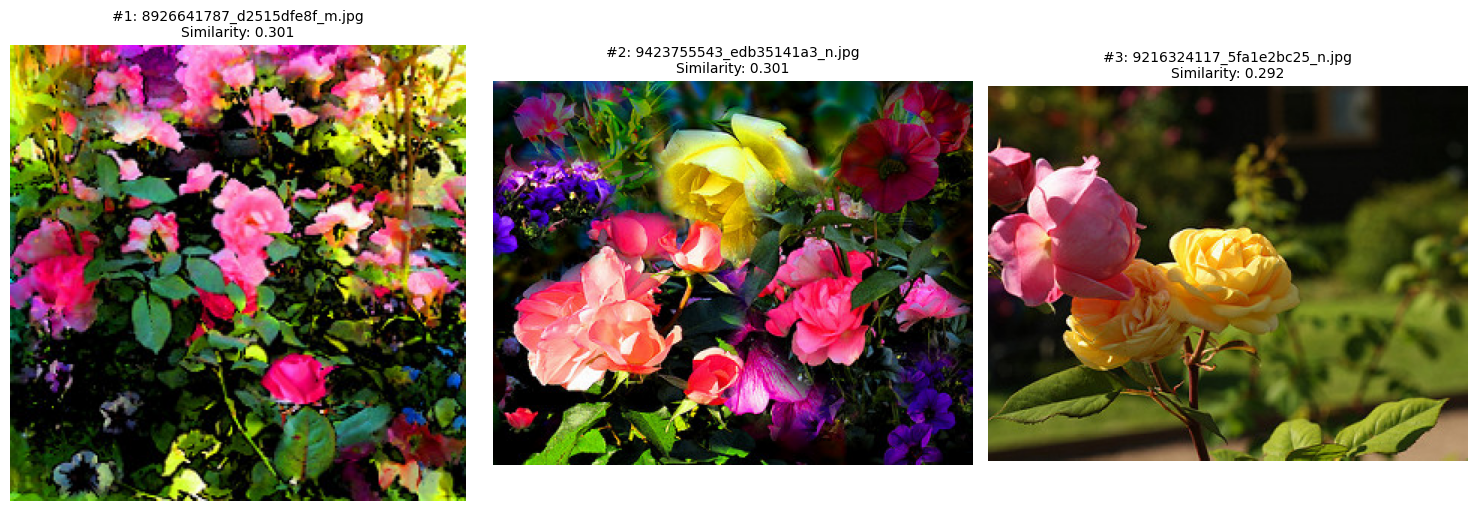


📋 All results:
   1. 8926641787_d2515dfe8f_m.jpg (similarity: 0.301)
   2. 9423755543_edb35141a3_n.jpg (similarity: 0.301)
   3. 9216324117_5fa1e2bc25_n.jpg (similarity: 0.292)
   4. 15274443248_76b9f3eb24.jpg (similarity: 0.291)
   5. 5835539224_75967fc400_m.jpg (similarity: 0.291)
   6. 8692040971_826614516f_n.jpg (similarity: 0.290)

🔍 Query: 'red dandellions'


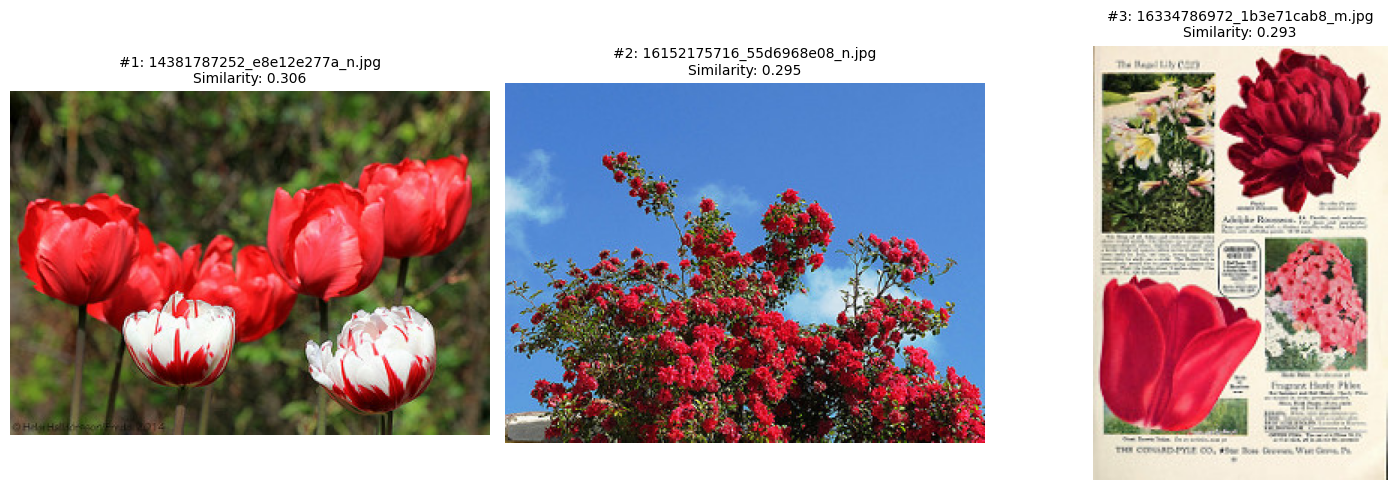


📋 All results:
   1. 14381787252_e8e12e277a_n.jpg (similarity: 0.306)
   2. 16152175716_55d6968e08_n.jpg (similarity: 0.295)
   3. 16334786972_1b3e71cab8_m.jpg (similarity: 0.293)
   4. 3145692843_d46ba4703c.jpg (similarity: 0.292)
   5. 6039330368_c30ed224c4_m.jpg (similarity: 0.288)
   6. 5234278003_d827fcd73b_m.jpg (similarity: 0.286)


In [12]:
search_queries = [
    "a dog playing",
    "beautiful sunset",
    "yellow tulips", 
    "red car",
    "flowers in garden",
    "red dandellions",
]

print("🎯 Testing multiple queries...")
print("You can modify the search_queries list above to test your own queries!")

for query in search_queries[0:6]:  # Show first 3 queries
    results = search_images(query, top_k=6)
    display_results(query, results, max_display=3)

In [14]:
#Explore Sample embeddings
def explore_embeddings():
    """Examine what embeddings look like and how they work"""
    print("🔬 EXPLORING EMBEDDINGS")
    print("=" * 40)
    
    # 1. Look at embedding dimensions
    print(f"📐 Embedding dimensions: {image_embeddings.shape}")
    print(f"   • {image_embeddings.shape[0]} images")
    print(f"   • {image_embeddings.shape[1]} features per embedding")
    
    # 2. Sample a few embeddings
    print(f"\n📊 Sample embedding values (first image, first 10 features):")
    sample_embedding = image_embeddings[0][:20]
    for i, val in enumerate(sample_embedding):
        print(f"   Feature {i+1:2d}: {val:8.4f}")
    
    return sample_embedding

# Show embedding exploration
sample_emb = explore_embeddings()

🔬 EXPLORING EMBEDDINGS
📐 Embedding dimensions: (13862, 512)
   • 13862 images
   • 512 features per embedding

📊 Sample embedding values (first image, first 10 features):
   Feature  1:  -0.0196
   Feature  2:   0.0273
   Feature  3:  -0.0134
   Feature  4:  -0.0133
   Feature  5:  -0.0861
   Feature  6:   0.0252
   Feature  7:  -0.0230
   Feature  8:  -0.0047
   Feature  9:   0.0501
   Feature 10:   0.0284
   Feature 11:   0.0350
   Feature 12:   0.0280
   Feature 13:  -0.0633
   Feature 14:  -0.0069
   Feature 15:  -0.0163
   Feature 16:  -0.0789
   Feature 17:   0.0249
   Feature 18:  -0.0119
   Feature 19:  -0.0050
   Feature 20:  -0.0136
